# E52 · Signals in two dimensions and one: bulk-surface reaction-diffusion in a cell, the cytosolic shortcut, and polarity

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Simulated: a 20 µm round cell (a 2-D cross-section) with a signaling protein that diffuses along the membrane, unbinds into the cytosol, diffuses there and rebinds; a photoactivation experiment imaged at six time points in the membrane and the cytosol. Rates are of the order reported for lipid-anchored and cytosolic signaling proteins |
| **You will learn** | **Bulk-surface reaction-diffusion**: a 2-D PDE in the cytosol coupled through a flux boundary condition to a 1-D PDE on the membrane · the two routes a signal can take (slow lateral diffusion in the membrane, fast excursions through the cytosol) and the length scales that decide between them · finite volumes on a disk and an exact **angular Fourier decomposition** that turns a 1,025-unknown PDE into 33 independent 17 × 17 problems · a **symmetrised eigen-solution** that is exact in time and differentiable in PyMC (`pt.linalg.eigh`) · **signal reach**: cytosolic deactivation gradients, front-to-back ratios and cell size · Bayesian inference of $D_m$, $D_c$, $k_{\text{on}}$, $k_{\text{off}}$ from photoactivation images, and what the membrane alone can tell you · a **misspecification lesson**: 1-D analyses of membrane spreading mistake the cytosolic shortcut for fast membrane diffusion (a threefold overestimate of $D_m$ with confident intervals), and LOO catches it · **polarity by wave-pinning**: why a cell can hold a front only if its membrane is slow and its cytosol is fast |

## Two compartments, one signal

When a receptor on one side of a cell is activated, the message has to travel. Many signaling
proteins (small GTPases such as Ras and Rho family members, lipid-anchored kinases, proteins
recruited by lipids like PIP₃) live on the inner face of the **membrane** part of the time
and in the **cytosol** the rest. On the membrane they diffuse slowly, in one dimension
around the cell's boundary (in this 2-D cross-section), at 0.1-1 µm²/s. In the cytosol they diffuse
10-100 times faster, in two dimensions, before they rebind somewhere else on the membrane.
Along the way they are switched off: by GAPs or phosphatases on the membrane, by
phosphatases in the cytosol. Which route a signal takes, how far it gets, and whether it reaches
the far side of the cell or its nucleus are set by a handful of diffusion and binding rates
and by the cell's size and shape.

This notebook builds the **bulk-surface reaction-diffusion** model that describes this, solves it
exactly and fast, fits it to (simulated) imaging data in PyMC, and uses the posterior to answer
questions a cell biologist asks: does the signal reach the back? Is the membrane spreading I see
real membrane diffusion? Can this cell hold a polarised front?

## The plan

1. The bulk-surface model
2. Finite volumes on a disk, and 33 small problems instead of one large one
3. How a pulse travels: along the membrane or through the cytosol
4. Signal reach: deactivation gradients and cell size
5. A photoactivation experiment
6. Fitting the bulk-surface model
7. What a 1-D analysis of the membrane gets wrong
8. From the posterior to signaling predictions
9. Polarity: a front that holds only if the membrane is slow and the cytosol fast

In [1]:
import logging
import time
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import pytensor.tensor as pt
import scipy.sparse as sp
from IPython.display import HTML
from matplotlib import animation
from scipy.linalg import expm
from scipy.sparse.linalg import splu

RANDOM_SEED = 52
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=FutureWarning)
BLUE, ORANGE, AQUA, GREY, PURPLE, RED, INK = (
    "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#8c5ac8", "#c8384e", "#222222")
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")

PyMC 6.3.2, ArviZ 1.3.0


## 1 · The bulk-surface model

Take a cross-section of a round cell: a disk $\Omega$ of radius $R$ (the cytosol, the **bulk**)
bounded by a circle $\Gamma$ (the membrane, the **surface**). Let $c(x, y, t)$ be the concentration
of the protein in the cytosol (per µm²) and $m(s, t)$ its concentration on the membrane (per µm of
membrane, $s$ the arc length). Then

$$\partial_t c = D_c \nabla^2 c - k_c\, c \qquad \text{in } \Omega,$$

$$\partial_t m = D_m\, \partial_s^2 m - k_m\, m + k_{\text{on}}\, c|_\Gamma - k_{\text{off}}\, m + \sigma(s, t) \qquad \text{on } \Gamma,$$

$$-D_c\, \partial_n c = k_{\text{off}}\, m - k_{\text{on}}\, c|_\Gamma \qquad \text{on } \Gamma.$$

The first line is 2-D diffusion with first-order deactivation (a cytosolic phosphatase, rate
$k_c$). The second is 1-D diffusion along the membrane with its own deactivation ($k_m$),
binding from the cytosol just under the membrane (rate constant $k_{\text{on}}$, in µm/s),
unbinding ($k_{\text{off}}$, per s) and a source $\sigma$ (activation by receptors). The third,
a **Robin boundary condition**, is the coupling: whatever unbinds from the membrane enters the
cytosol there, and whatever binds leaves it. Without deactivation the total amount
$\int_\Omega c + \int_\Gamma m$ is conserved.

Four length and time scales organise everything that follows:

| scale | formula | meaning |
|---|---|---|
| membrane run length | $\ell_m = \sqrt{D_m / (k_{\text{off}} + k_m)}$ | how far a molecule travels along the membrane before it leaves or is switched off |
| cytosolic reach | $\ell_c = \sqrt{D_c / k_c}$ | how far an active molecule gets into the cytosol before a phosphatase catches it (Brown & Kholodenko 1999) |
| residence time | $1 / k_{\text{off}}$ | how long a molecule stays on the membrane per visit |
| crossing time | $R^2 / D_c$ | how long a cytosolic excursion takes to cross the cell |

With $D_m = 0.3$ µm²/s and $k_{\text{off}} = 0.2$ /s, $\ell_m \approx 1.2$ µm, a few percent of the
63 µm perimeter of a 20 µm cell. A signal that stayed on the membrane would need
$(\pi R)^2 / 2D_m \approx 30$ minutes to even out around the cell. Through the cytosol, with
$D_c = 10$ µm²/s, a crossing takes about 10 s.

## 2 · Finite volumes on a disk, and 33 small problems instead of one large one

We cut the disk into a central cell and 15 rings of 64 sectors (961 cytosolic volumes), and the
membrane into the 64 arcs that bound the outer ring. Writing the balance of each volume
(diffusive fluxes through its faces, deactivation, exchange with the membrane arc above it)
gives a linear system of ODEs

$$M\, \dot u = -K(\theta)\, u + f, \qquad K(\theta) = D_c K_{D_c} + D_m K_{D_m} + k_{\text{on}} K_{\text{on}} + k_{\text{off}} K_{\text{off}} + k_c K_c + k_m K_m,$$

where $u$ stacks the 1,025 concentrations, $M$ is the diagonal of cell areas and arc lengths, and
each $K_\bullet$ is a fixed sparse matrix built once from the geometry. $K$ is **linear in the
parameters**, which is what makes the model cheap in PyMC.

Two exact tricks make it cheaper still.

- **Rotational symmetry.** Every ring is a circulant: rotating the cell by one sector maps the
  mesh to itself. So the operator is block-diagonal in angular Fourier modes: for each mode
  $\cos(n\theta)$, $n = 0, \dots, 32$, only a radial problem remains, with unknowns
  [centre, 15 rings, membrane]. A stimulus symmetric about the front ($\theta = 0$) needs only
  the cosine modes. One 1,025 × 1,025 system becomes 33 independent 17 × 17 systems.
- **Symmetrisation.** $K$ is not symmetric (binding and unbinding rates differ), but scaling the
  membrane equations by $k_{\text{off}} / k_{\text{on}}$ makes it so (a detailed-balance weighting).
  Then $B = (WM)^{-1/2}\, WK\, (WM)^{-1/2}$ is symmetric, `eigh` diagonalises it with real
  eigenvalues, and the solution at any time is exact:
  $u(t) = (WM)^{-1/2}\, V e^{-\Lambda t} V^\top (WM)^{1/2}\, u(0)$. `pt.linalg.eigh` has a
  gradient, so this goes straight into a PyMC model: no time stepping, no stiffness.

The mesh is built for $R_0 = 10$ µm; other cell sizes follow by scaling each $K_\bullet$ with its
power of $R$ (the cytosolic conductances are dimensionless in 2-D, membrane conductances scale
as $1/R$, exchange as $R$, areas as $R^2$).

In [2]:
R0, NR, NT = 10.0, 16, 64                       # radius (um), radial cells, sectors
DR, DTH = R0 / NR, 2 * np.pi / NT
TH = np.arange(NT) * DTH                        # sector centres; 0 = the front of the cell
TH = np.where(TH > np.pi, TH - 2 * np.pi, TH)   # in (-pi, pi]
NB = 1 + (NR - 1) * NT                          # cytosolic volumes
NTOT = NB + NT                                  # + membrane arcs
LSEG = R0 * DTH


def bidx(j, i):
    """Index of cytosolic volume in ring j (1..NR-1), sector i."""
    return 1 + (j - 1) * NT + (i % NT)


AREA = np.empty(NB)
AREA[0] = np.pi * DR**2
for j in range(1, NR):
    AREA[bidx(j, 0): bidx(j, 0) + NT] = ((j + 1) ** 2 - j**2) * DR**2 * DTH / 2
MASS = np.r_[AREA, np.full(NT, LSEG)]
OUTER = np.array([bidx(NR - 1, i) for i in range(NT)])      # cytosol just under each membrane arc
PARAMS = ["Dc", "Dm", "kon", "koff", "kc", "km"]
R_POWER = dict(Dc=0, Dm=-1, kon=1, koff=1, kc=2, km=1)       # how each K scales with R


def build_basis():
    B = {p: sp.lil_matrix((NTOT, NTOT)) for p in PARAMS}

    def link(p, a, b, g):                                     # diffusive exchange between a and b
        B[p][a, a] += g; B[p][b, b] += g; B[p][a, b] -= g; B[p][b, a] -= g

    for i in range(NT):
        link("Dc", 0, bidx(1, i), DTH / 1.5)                  # centre <-> ring 1
        for j in range(1, NR):
            link("Dc", bidx(j, i), bidx(j, i + 1), 1.0 / ((j + 0.5) * DTH))   # around the ring
            if j < NR - 1:
                link("Dc", bidx(j, i), bidx(j + 1, i), (j + 1) * DTH)         # outwards
        link("Dm", NB + i, NB + (i + 1) % NT, 1.0 / LSEG)                     # along the membrane
        a, m = OUTER[i], NB + i
        B["kon"][a, a] += LSEG; B["kon"][m, a] -= LSEG        # binding: cytosol -> membrane
        B["koff"][m, m] += LSEG; B["koff"][a, m] -= LSEG      # unbinding: membrane -> cytosol
    B["kc"].setdiag(np.r_[AREA, np.zeros(NT)])
    B["km"].setdiag(np.r_[np.zeros(NB), np.full(NT, LSEG)])
    return {p: B[p].tocsr() for p in PARAMS}


BASIS = build_basis()

# cosine-mode projection: per mode n, coordinates [centre, ring 1..NR-1, membrane]
NMODE, S = NT // 2 + 1, NR + 1
COS = np.cos(np.outer(TH, np.arange(NMODE)))
COSN = COS / np.linalg.norm(COS, axis=0)                     # orthonormal columns
P = np.zeros((NMODE, NTOT, S))
for n in range(NMODE):
    P[n, 0, 0] = 1.0 if n == 0 else 0.0                       # the centre only sees mode 0
    for j in range(1, NR):
        P[n, bidx(j, 0): bidx(j, 0) + NT, j] = COSN[:, n]
    P[n, NB:, NR] = COSN[:, n]
MODE_BASIS = {p: np.stack([P[n].T @ (BASIS[p] @ P[n]) for n in range(NMODE)]) for p in PARAMS}
MODE_MASS = np.einsum("nas,a->ns", P**2, MASS)
DUMMY = np.zeros((NMODE, S, S))
DUMMY[1:, 0, 0] = 1.0                                         # decoupled placeholder for the centre
MODE_MASS[1:, 0] = 1.0


def to_modes(u):
    return np.einsum("nas,...a->...ns", P, u)


def from_modes(a):
    return np.einsum("nas,...ns->...a", P, a)


def mode_system(th, R=R0):
    """K (NMODE, S, S) and M (NMODE, S) in the cosine-mode basis for parameters th and radius R."""
    sc = R / R0
    K = sum(th.get(p, 0.0) * sc ** R_POWER[p] * MODE_BASIS[p] for p in PARAMS) + DUMMY
    M = MODE_MASS * np.r_[np.full(S - 1, sc**2), sc]
    M[1:, 0] = 1.0
    return K, M


def evolve(th, u0, times, R=R0):
    """Exact u(t) for dM u/dt = -K u from u(0) = u0 (full-mesh vectors), via symmetrised eigh."""
    K, M = mode_system(th, R)
    w = np.ones_like(M)
    w[:, -1] = th["koff"] / th["kon"]
    s = np.sqrt(w * M)
    lam, V = np.linalg.eigh(w[:, :, None] * K / s[:, :, None] / s[:, None, :])
    a = np.einsum("nsk,tnk,nqk,nq->tns", V, np.exp(-lam[None] * np.asarray(times)[:, None, None]),
                  V, s * to_modes(u0)) / s
    return from_modes(a)


def steady(th, source, R=R0):
    """Steady state for a constant membrane source (per um of membrane per s), needs kc or km > 0."""
    K, M = mode_system(th, R)
    f = to_modes(np.r_[np.zeros(NB), source]) * np.r_[np.zeros(S - 1), LSEG * R / R0]   # amounts / s
    return from_modes(np.linalg.solve(K, f[..., None])[..., 0])


TRUE = dict(Dc=10.0, Dm=0.3, kon=2.3, koff=0.2)                # the "real" protein of sections 5-8
PATCH = (np.abs(TH) < np.deg2rad(20)).astype(float)            # a 40-degree patch at the front
u0 = np.r_[np.zeros(NB), PATCH]

# check the mode solution against the full 1,025-unknown system (dense matrix exponential)
t0 = time.time()
u_full = expm(-(BASIS["Dc"] * TRUE["Dc"] + BASIS["Dm"] * TRUE["Dm"] + BASIS["kon"] * TRUE["kon"]
                + BASIS["koff"] * TRUE["koff"]).toarray() / MASS[:, None] * 10.0) @ u0
t_full = time.time() - t0
t0 = time.time()
u_mode = evolve(TRUE, u0, [10.0])[0]
t_mode = time.time() - t0
print(f"max |mode - full| at t = 10 s: {np.abs(u_mode - u_full).max():.1e} (peak {u_full.max():.2f}); "
      f"full expm {1000 * t_full:.0f} ms, modes {1000 * t_mode:.1f} ms")
print(f"total amount: start {MASS @ u0:.6f}, t = 10 s {MASS @ u_mode:.6f}")
eq_frac = 2 * TRUE["kon"] / (TRUE["koff"] * R0) / (1 + 2 * TRUE["kon"] / (TRUE["koff"] * R0))
print(f"equilibrium membrane fraction 2kon/(koff R) / (1 + ...) = {eq_frac:.2f}; "
      f"membrane run length {np.sqrt(TRUE['Dm'] / TRUE['koff']):.2f} um")

max |mode - full| at t = 10 s: 9.2e-14 (peak 0.35); full expm 196 ms, modes 1.1 ms
total amount: start 6.872234, t = 10 s 6.872234
equilibrium membrane fraction 2kon/(koff R) / (1 + ...) = 0.70; membrane run length 1.22 um


The 33 small eigen-problems reproduce the dense matrix exponential of the full system to rounding
error, about a hundred times faster, and conserve the total amount. At equilibrium 70% of this protein
sits on the membrane.

## 3 · How a pulse travels: along the membrane or through the cytosol

Suppose the protein is switched on (photoactivated, say) in a 40° patch of membrane at the front
of the cell, and then left alone. Four versions of the same protein:

- **membrane only**: it never unbinds; the membrane is its whole world;
- **rarely unbinds**: $k_{\text{off}} = 0.002$ /s, a residence of 8 minutes per visit;
- **exchanging**: the protein above, residence 5 s, $D_c = 10$ µm²/s;
- **exchanging, slow cytosol**: the same binding, $D_c = 0.5$ µm²/s (a large complex, or
  crowded cytoplasm).

$k_{\text{on}}$ scales with $k_{\text{off}}$ so all of them would keep 70% on the membrane at
equilibrium. The cell images below show the cytosol inside and the membrane as the outer ring,
each on its own colour scale (the membrane is 30-100 times more concentrated).

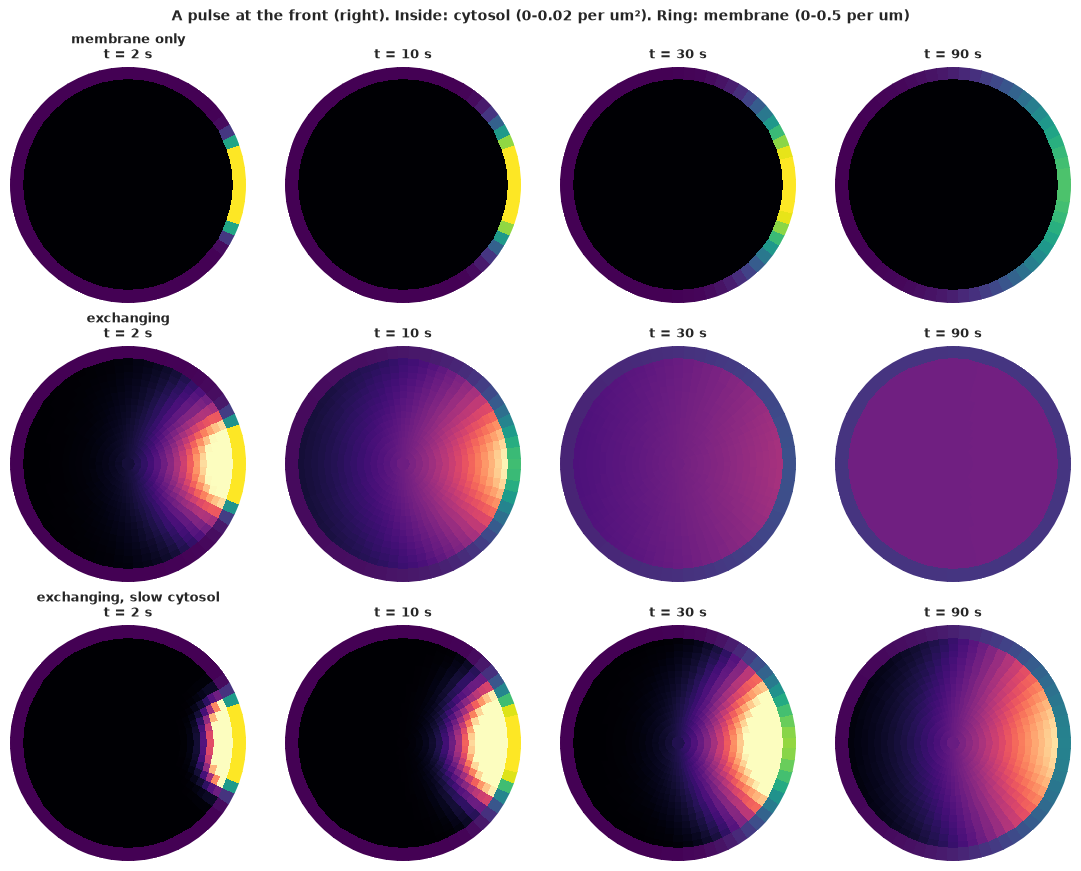

In [3]:
REGIMES = {
    "membrane only": dict(Dc=10.0, Dm=0.3, kon=1.15e-8, koff=1e-9),
    "rarely unbinds": dict(Dc=10.0, Dm=0.3, kon=0.023, koff=0.002),
    "exchanging": TRUE,
    "exchanging, slow cytosol": dict(Dc=0.5, Dm=0.3, kon=2.3, koff=0.2),
}
SNAP_T = [2.0, 10.0, 30.0, 90.0]
RING_EDGES = np.r_[0.0, np.arange(1, NR + 1) * DR]
TH_EDGES = (np.arange(NT + 1) - 0.5) * DTH


def cell_image(ax, u, cmax, mmax, title="", R=R0, cmin=0.0):
    """Polar image: cytosol (magma) and a membrane band (viridis) outside radius R."""
    grid = np.empty((NR, NT))
    grid[0] = u[0]
    for j in range(1, NR):
        grid[j] = u[bidx(j, 0): bidx(j, 0) + NT]
    ax.pcolormesh(TH_EDGES, RING_EDGES * R / R0, grid, cmap="magma", vmin=cmin, vmax=cmax, shading="flat")
    ax.pcolormesh(TH_EDGES, np.array([1.0, 1.12]) * R, u[NB:][None, :], cmap="viridis", vmin=0,
                  vmax=mmax, shading="flat")
    ax.set_ylim(0, 1.12 * R)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False); ax.spines["polar"].set_visible(False)
    ax.set_title(title, fontsize=9)


SHOW = ["membrane only", "exchanging", "exchanging, slow cytosol"]
pulse = {name: evolve(REGIMES[name], u0, SNAP_T) for name in SHOW}
fig, axes = plt.subplots(3, 4, figsize=(11, 8.6), subplot_kw=dict(projection="polar"))
for r, (name, U) in enumerate(pulse.items()):
    for c, t in enumerate(SNAP_T):
        cell_image(axes[r, c], U[c], cmax=0.02, mmax=0.5, title=f"{name}\nt = {t:.0f} s" if c == 0 else f"t = {t:.0f} s")
fig.suptitle("A pulse at the front (right). Inside: cytosol (0-0.02 per um²). Ring: membrane (0-0.5 per um)", fontsize=10);

The animation below plays the same three cells continuously from 0.5 s to 2 minutes (time runs
on a log scale, so the fast early exchange and the slow late spreading both get frames).

In [4]:
T_ANIM = np.geomspace(0.5, 120, 40)
pulse_anim = {name: evolve(REGIMES[name], u0, T_ANIM) for name in SHOW}
fig, axes = plt.subplots(1, 3, figsize=(10.5, 4), dpi=72, subplot_kw=dict(projection="polar"))
suptitle = fig.suptitle("")
plt.close(fig)


def update(k):
    for ax, name in zip(axes, SHOW):
        ax.clear()
        cell_image(ax, pulse_anim[name][k], cmax=0.02, mmax=0.5, title=name)
    suptitle.set_text(f"t = {T_ANIM[k]:5.1f} s after the pulse")
    return []


anim = animation.FuncAnimation(fig, update, frames=len(T_ANIM), interval=150)
HTML(anim.to_jshtml(default_mode="once"))

The membrane-only protein spreads by a few µm in 90 s and never reaches the back. The exchanging
protein leaks into the cytosol at the patch, crosses the cell in seconds and **rebinds all around
the membrane**: by 30 s the membrane is nearly uniform. With a slow cytosol the molecules still
leave the membrane, but they rebind close to where they left, and the signal stays at the front,
now as a cytosolic cloud under the patch.

Two summaries make this quantitative. The first is the spread of the membrane signal, measured as
the mean squared arc distance from the front. Pure membrane diffusion gives $2 D_m t$. Excursions
through the cytosol are occasional long jumps: in an infinite medium this is **bulk-mediated
surface diffusion**, which is superdiffusive (Bychuk & O'Shaughnessy 1995). The second is the
fraction of the membrane signal that has reached the back half of the cell.

membrane only             : 10% of the membrane signal at the back after    165 s
rarely unbinds            : 10% of the membrane signal at the back after    132 s
exchanging                : 10% of the membrane signal at the back after     10 s
exchanging, slow cytosol  : 10% of the membrane signal at the back after     99 s


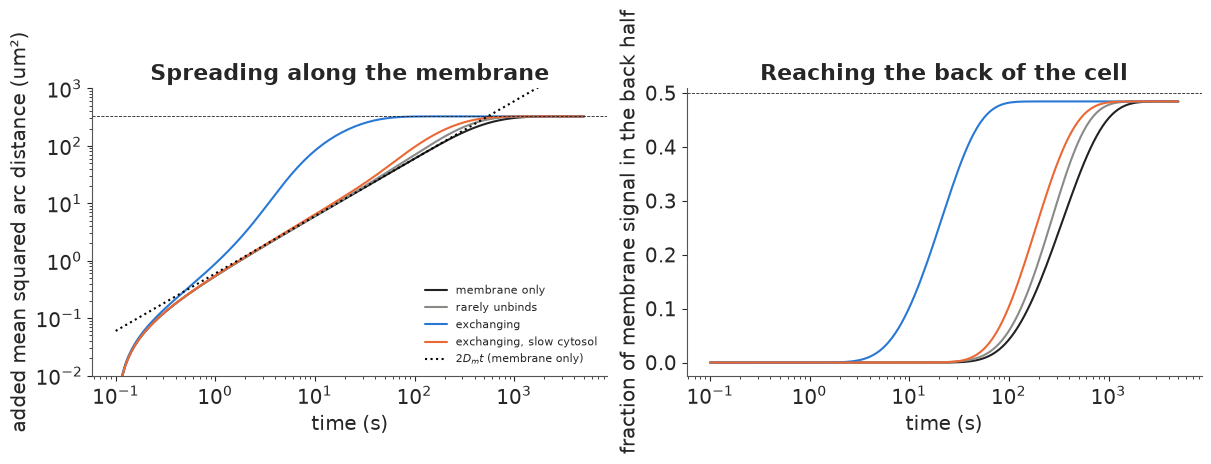

In [5]:
T_GRID = np.geomspace(0.1, 5000, 150)
ARC = R0 * TH
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
colors = dict(zip(REGIMES, [INK, GREY, BLUE, ORANGE]))
back = np.abs(TH) > np.pi / 2
for name, th in REGIMES.items():
    U = evolve(th, u0, T_GRID)[:, NB:]
    msd = (U * ARC**2).sum(1) / U.sum(1)
    axes[0].loglog(T_GRID, msd - msd[0], color=colors[name], label=name)
    frac_back = U[:, back].sum(1) / U.sum(1)
    axes[1].semilogx(T_GRID, frac_back, color=colors[name], label=name)
    hit = T_GRID[np.argmax(frac_back > 0.1)] if (frac_back > 0.1).any() else np.nan
    print(f"{name:26s}: 10% of the membrane signal at the back after {hit:6.0f} s")
axes[0].loglog(T_GRID, 2 * TRUE["Dm"] * T_GRID, "k:", label="$2 D_m t$ (membrane only)")
axes[0].axhline((np.pi * R0) ** 2 / 3 - (ARC[PATCH > 0] ** 2).mean(), color=INK, lw=0.6, ls="--")
axes[0].set(xlabel="time (s)", ylabel="added mean squared arc distance (um²)", ylim=(1e-2, 1e3),
            title="Spreading along the membrane")
axes[0].legend(fontsize=8)
axes[1].axhline(0.5, color=INK, lw=0.6, ls="--")
axes[1].set(xlabel="time (s)", ylabel="fraction of membrane signal in the back half",
            title="Reaching the back of the cell");

On the left, the membrane-only protein follows $2 D_m t$ until, after about half an hour, it
saturates at the uniform distribution (dashed line). The exchanging protein spreads **faster than
any 1-D diffusion** once its molecules start to leave the membrane (after about one residence
time) and reaches the uniform distribution in about a minute. On the right, the back half of the
membrane holds 10% of the signal after 10 s through the cytosol, against nearly 3 minutes by
membrane diffusion alone (printout).

The two other cases show what the shortcut needs. A protein that **rarely** unbinds (once per 8
minutes) gains about 20%: the few molecules that make the jump land anywhere on the membrane,
but too few make it in the first minutes. A protein whose cytosolic phase is **slow** gains not
much more: its molecules spend 30% of their time in the cytosol but land close to where they
took off, so its spread along the membrane is almost exactly membrane diffusion (left). The
shortcut needs both frequent exchange and fast cytosolic diffusion.

That is the central point of the bulk-surface picture: **long-range transport along the
membrane is set by the cytosol**, and short-range structure (the edge of the patch) by the
membrane. Section 7 shows what happens when a data analysis ignores this.

## 4 · Signal reach: deactivation gradients and cell size

Now the protein is a **signal**: receptors at the front activate it at a constant rate, a GAP
switches it off on the membrane ($k_m = 0.05$ /s) and a phosphatase switches it off in the
cytosol ($k_c$). At steady state, how much active protein is there at the back of the cell,
and at its centre, where the nucleus sits? The answer depends on the cytosolic reach
$\ell_c = \sqrt{D_c/k_c}$ compared with the cell radius: this is the argument of Brown &
Kholodenko (1999) and Meyers, Craig & Odde (2006) that phosphatases make signals local and that
cell size and shape control signaling.

R =    5 um, k_c = 1/s: back/front 1.8e-02, centre/front 1.7e-01
R =   10 um, k_c = 1/s: back/front 6.7e-04, centre/front 3.5e-02
R =   20 um, k_c = 1/s: back/front 1.4e-06, centre/front 2.6e-03


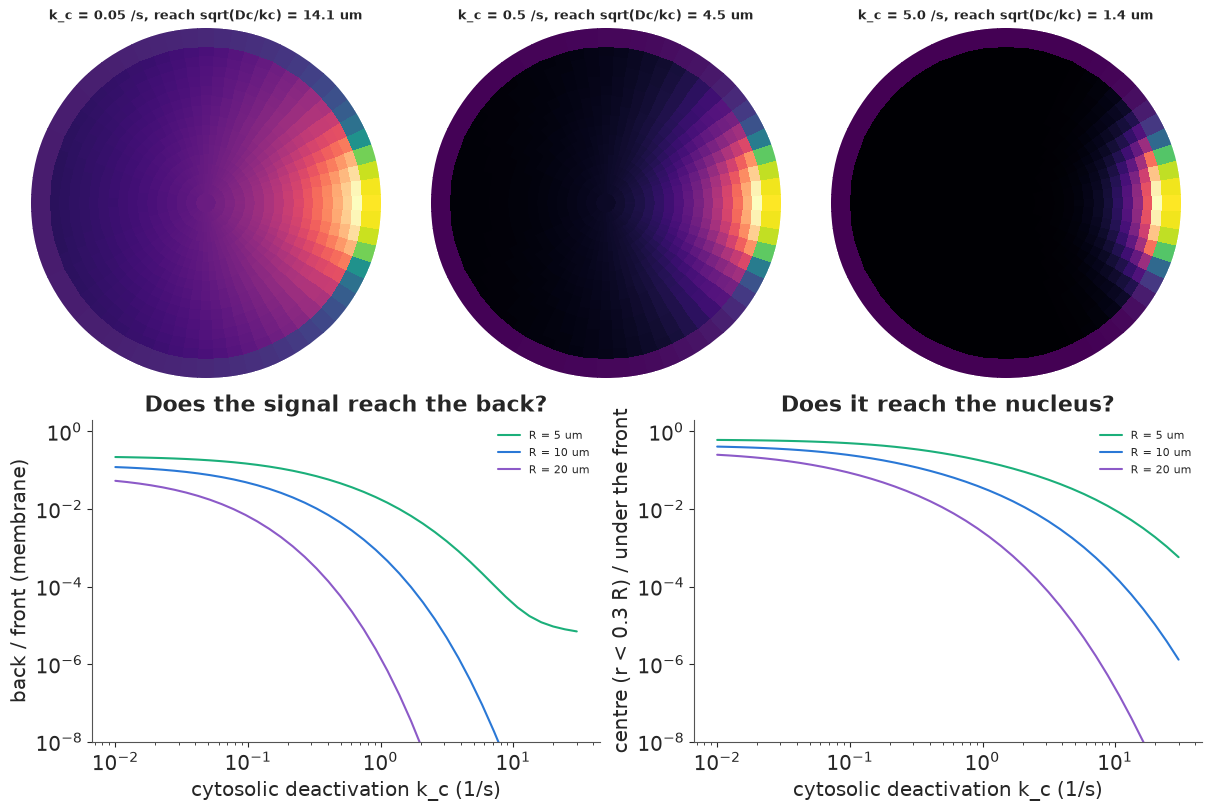

In [6]:
KM = 0.05
SOURCE = PATCH.copy()
CENTRE = np.r_[0, np.concatenate([np.arange(bidx(j, 0), bidx(j, 0) + NT) for j in range(1, 5)])]  # r < 3 um


def reach(th, R=R0):
    """Back/front membrane ratio and centre / sub-front cytosol ratio at steady state."""
    u = steady(th, SOURCE, R)
    front_m, back_m = u[NB:][np.abs(TH) < 0.05].mean(), u[NB:][np.abs(TH) > np.pi - 0.05].mean()
    front_c = u[OUTER][np.abs(TH) < 0.05].mean()
    centre = (u[CENTRE] * AREA[CENTRE]).sum() / AREA[CENTRE].sum()
    return back_m / front_m, centre / front_c, u


KC_SHOW = [0.05, 0.5, 5.0]
fig = plt.figure(figsize=(12, 8))
top, bottom = fig.subfigures(2, 1, height_ratios=[1, 1.1])
for c, kc in enumerate(KC_SHOW):
    ax = top.add_subplot(1, 3, c + 1, projection="polar")
    _, _, u = reach(dict(TRUE, kc=kc, km=KM))
    cell_image(ax, u / u[NB:].max(), cmax=u[:NB].max() / u[NB:].max(), mmax=1.0,
               title=f"k_c = {kc} /s, reach sqrt(Dc/kc) = {np.sqrt(TRUE['Dc'] / kc):.1f} um")
KC_GRID = np.geomspace(0.01, 30, 40)
ax_b, ax_c = bottom.subplots(1, 2)
for R, col in zip([5.0, 10.0, 20.0], [AQUA, BLUE, PURPLE]):
    rr = np.array([reach(dict(TRUE, kc=kc, km=KM), R)[:2] for kc in KC_GRID])
    ax_b.loglog(KC_GRID, rr[:, 0], color=col, label=f"R = {R:.0f} um")
    ax_c.loglog(KC_GRID, rr[:, 1], color=col, label=f"R = {R:.0f} um")
    b1, c1 = reach(dict(TRUE, kc=1.0, km=KM), R)[:2]
    print(f"R = {R:4.0f} um, k_c = 1/s: back/front {b1:.1e}, centre/front {c1:.1e}")
ax_b.set(xlabel="cytosolic deactivation k_c (1/s)", ylabel="back / front (membrane)",
         title="Does the signal reach the back?", ylim=(1e-8, 2))
ax_c.set(xlabel="cytosolic deactivation k_c (1/s)", ylabel="centre (r < 0.3 R) / under the front",
         title="Does it reach the nucleus?", ylim=(1e-8, 2))
ax_b.legend(fontsize=8); ax_c.legend(fontsize=8);

Top row, with the protein above: a slow phosphatase ($\ell_c = 14$ µm) lets the active form fill
the cytosol and rebind everywhere. A fast one ($\ell_c = 1.4$ µm) leaves a thin active layer under
the front and nothing reaches the centre. The curves (bottom) quantify this. Back-to-front ratios
fall steeply once $\ell_c$ drops below the radius, and **larger cells lose the back and the
nucleus first** (printout: at $k_c = 1$ /s the centre of a 5 µm-radius cell gets 17% of the
level under the front, a 20 µm-radius cell 0.3%). At large $k_c$ the back-to-front curves
flatten: the cytosolic route is closed and what is left is the membrane route,
$\sim e^{-\pi R/\ell_m}$ with $\ell_m \approx 1$ µm, which is negligible for all but the
smallest cell. For any cell of ordinary size, **a signal that reaches the back arrives through
the cytosol**.

## 5 · A photoactivation experiment

How would we know $D_m$, $D_c$, $k_{\text{on}}$, $k_{\text{off}}$ for a real protein? A standard
experiment: tag the protein with a photoactivatable fluorophore, activate a 40° patch of membrane
with a laser, and image the cell at 1, 3, 6, 12, 24 and 48 s. Each image gives the intensity in
the 64 membrane arcs and in the 961 cytosolic volumes (intensities in units of the initial patch
intensity). The camera adds noise with standard deviation 0.02 in those units: the membrane
signal is bright, but the cytosol, at 0.01-0.03, is at a signal-to-noise ratio of about one per
pixel. There is no deactivation: the fluorophore stays on. The data are simulated from the
"exchanging" protein.

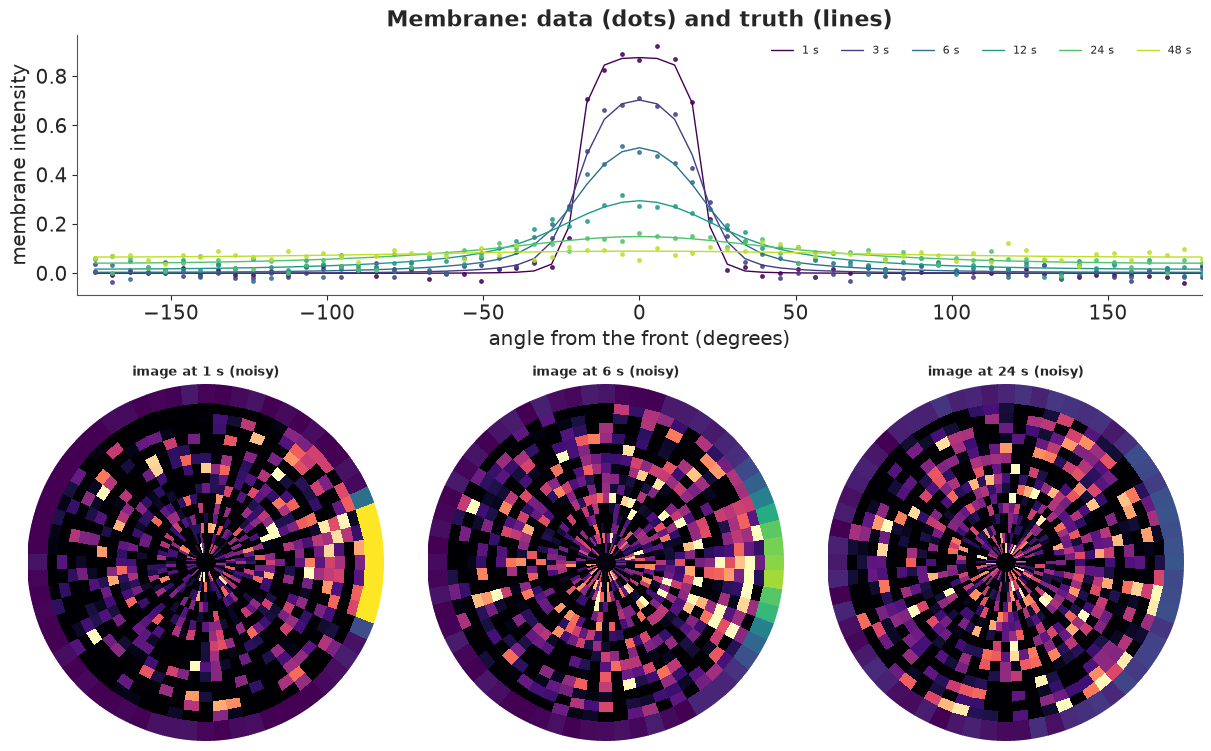

In [7]:
TIMES = np.array([1.0, 3.0, 6.0, 12.0, 24.0, 48.0])
SIG_TRUE = 0.02
U_true = evolve(TRUE, u0, TIMES)
Y = U_true + SIG_TRUE * rng.standard_normal(U_true.shape)
Y_mem, Y_cyt = Y[:, NB:], Y[:, :NB]

order = np.argsort(TH)
fig = plt.figure(figsize=(12, 7.4))
top, bottom = fig.subfigures(2, 1, height_ratios=[1, 1.1])
ax = top.subplots()
tcol = plt.cm.viridis(np.linspace(0, 0.9, len(TIMES)))
for k, t in enumerate(TIMES):
    ax.plot(np.rad2deg(TH[order]), Y_mem[k, order], "o", ms=2.5, color=tcol[k], alpha=0.8)
    ax.plot(np.rad2deg(TH[order]), U_true[k, NB:][order], color=tcol[k], lw=1, label=f"{t:.0f} s")
ax.set(xlabel="angle from the front (degrees)", ylabel="membrane intensity",
       title="Membrane: data (dots) and truth (lines)", xlim=(-180, 180))
ax.legend(ncol=6, fontsize=8)
for c, k in enumerate([0, 2, 4]):
    axp = bottom.add_subplot(1, 3, 1 + c, projection="polar")
    cell_image(axp, Y[k].clip(0), cmax=0.05, mmax=0.6, title=f"image at {TIMES[k]:.0f} s (noisy)")

The membrane profile flattens and drops as molecules leave the patch, and the far side of the
membrane rises from zero to about 0.07 by 48 s. In the cytosol the signal is barely visible in any
single pixel: a cloud under the patch at 1 s that spreads through the cell by 12 s.

## 6 · Fitting the bulk-surface model

The PyMC model is the solution of section 2 written in PyTensor: build the 33 mode matrices from
the parameters, symmetrise, `pt.linalg.eigh` (batched over modes), propagate each eigenmode in
time, and project back to the membrane arcs and cytosolic volumes. Priors are wide (a factor of
about 3 either way, one standard deviation on the log scale) and centred away from the truth:
$D_c \sim$ LogNormal(log 10, 1), $D_m \sim$ LogNormal(log 0.5, 1),
$k_{\text{on}} \sim$ LogNormal(log 1, 1), $k_{\text{off}} \sim$ LogNormal(log 0.2, 1).
We fit it twice: to the membrane and cytosol images, and to the membrane profile alone (what a
confocal ring-intensity analysis would use).

In [8]:
MB = {p: pt.as_tensor(MODE_BASIS[p]) for p in ["Dc", "Dm", "kon", "koff"]}
A0 = to_modes(u0)


def bulk_surface_model(use_cytosol=True):
    with pm.Model() as model:
        Dc = pm.LogNormal("Dc", np.log(10), 1.0)
        Dm = pm.LogNormal("Dm", np.log(0.5), 1.0)
        kon = pm.LogNormal("kon", np.log(1), 1.0)
        koff = pm.LogNormal("koff", np.log(0.2), 1.0)
        sigma = pm.HalfNormal("sigma", 0.05)
        K = Dc * MB["Dc"] + Dm * MB["Dm"] + kon * MB["kon"] + koff * MB["koff"] + DUMMY
        w = pt.concatenate([pt.ones((NMODE, S - 1)), pt.ones((NMODE, 1)) * koff / kon], axis=1)
        s = pt.sqrt(w * MODE_MASS)
        B = w[:, :, None] * K / s[:, :, None] / s[:, None, :]
        lam, V = pt.linalg.eigh(0.5 * (B + B.transpose(0, 2, 1)))
        a = pt.einsum("nsk,tnk,nqk,nq->tns", V, pt.exp(-lam[None] * TIMES[:, None, None]), V, s * A0) / s
        u = pt.einsum("nas,tns->ta", P, a)
        pm.Normal("y_mem", u[:, NB:], sigma, observed=Y_mem)
        if use_cytosol:
            pm.Normal("y_cyt", u[:, :NB], sigma, observed=Y_cyt)
    return model


fits = {}
for label, use_cyt in [("bulk-surface, membrane + cytosol", True), ("bulk-surface, membrane only", False)]:
    t0 = time.time()
    with bulk_surface_model(use_cyt):
        idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
        pm.compute_log_likelihood(idata, var_names=["y_mem"], progressbar=False)
    fits[label] = idata
    summ = az.summary(idata, var_names=["Dc", "Dm", "kon", "koff"], round_to=3)
    summ["truth"] = [TRUE[p] for p in ["Dc", "Dm", "kon", "koff"]]
    print(f"{label}: {time.time() - t0:.0f} s, {int(idata.sample_stats['diverging'].sum())} divergences")
    print(summ[["mean", "sd", "eti89_lb", "eti89_ub", "ess_bulk", "r_hat", "truth"]], "\n")

bulk-surface, membrane + cytosol: 61 s, 0 divergences
        mean     sd  eti89_lb  eti89_ub  ess_bulk  r_hat  truth
Dc    10.341  0.689     9.298    11.495  1678.564  1.001   10.0
Dm     0.313  0.024     0.274     0.353  1380.449  1.002    0.3
kon    2.258  0.225     1.926     2.635   939.506  1.004    2.3
koff   0.192  0.014     0.171     0.215   864.752  1.002    0.2 



bulk-surface, membrane only: 64 s, 0 divergences
        mean     sd  eti89_lb  eti89_ub  ess_bulk  r_hat  truth
Dc    10.532  1.012     9.047    12.284  1510.550  1.002   10.0
Dm     0.315  0.027     0.274     0.358  1482.409  1.003    0.3
kon    2.262  0.266     1.850     2.720  1132.259  1.005    2.3
koff   0.191  0.017     0.165     0.220   992.566  1.006    0.2 



Both fits recover all four parameters within their intervals, with no divergences. The
surprise is the second fit: **the membrane profile alone identifies the cytosolic diffusion
coefficient**, nearly as well as the images that include the cytosol. The cytosol leaves a
fingerprint on the membrane: molecules that left the patch rebind at distances set by $D_c$ and
$k_{\text{on}}$ (fast diffusion spreads them evenly around the ring, slow diffusion keeps them near
the front), and the rising baseline at the far side of the membrane in section 5 is that
fingerprint. The joint posterior shows which combinations the data pin down.

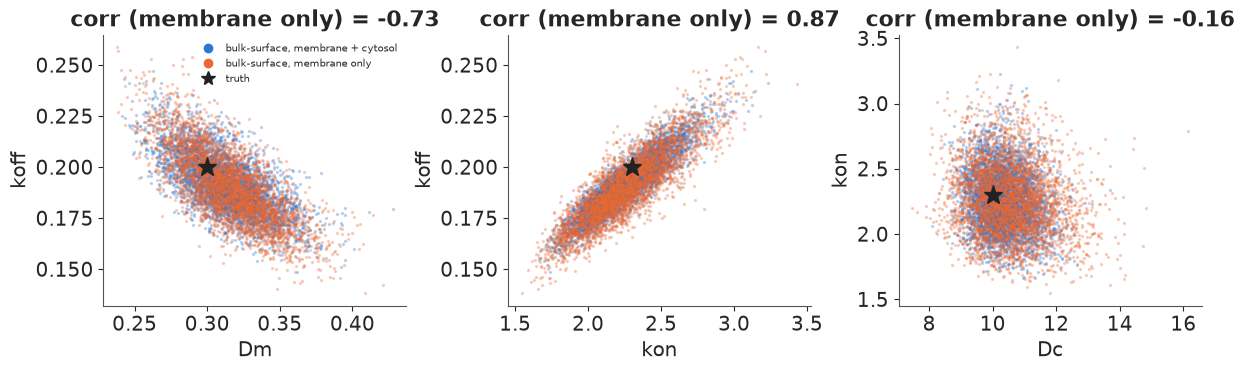

In [9]:
post = {k: v.posterior.to_dataset().stack(sample=("chain", "draw")) for k, v in fits.items()}
pairs = [("Dm", "koff"), ("kon", "koff"), ("Dc", "kon")]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, (a_, b_) in zip(axes, pairs):
    for (label, p), col in zip(post.items(), [BLUE, ORANGE]):
        ax.scatter(p[a_], p[b_], s=2, alpha=0.25, color=col, label=label)
    ax.plot(TRUE[a_], TRUE[b_], "*", ms=14, color=INK, label="truth")
    r = np.corrcoef(post["bulk-surface, membrane only"][a_], post["bulk-surface, membrane only"][b_])[0, 1]
    ax.set(xlabel=a_, ylabel=b_, title=f"corr (membrane only) = {r:.2f}")
handles = [plt.Line2D([], [], ls="", marker="o", color=c_, label=l_) for c_, l_ in zip([BLUE, ORANGE], post)]
axes[0].legend(handles=[*handles, plt.Line2D([], [], ls="", marker="*", ms=10, color=INK, label="truth")], fontsize=7);

$k_{\text{on}}$ and $k_{\text{off}}$ are strongly correlated: their ratio sets the equilibrium
membrane fraction, which the data determine well, while their common scale (how fast the
exchange is) is less certain. The cytosol images mostly narrow $D_c$ and the binding rates.

## 7 · What a 1-D analysis of the membrane gets wrong

The usual analysis of membrane spreading (FRAP or photoactivation on a membrane) treats the
membrane as the whole world: a 1-D diffusion equation along the membrane, perhaps with a loss term
for molecules that leave. A second, better-informed simplification keeps the exchange but assumes
the cytosol is **well mixed** (the limit $D_c \to \infty$): molecules that unbind join a
uniform pool and rebind anywhere with equal probability. This is the "reaction-dominant"
simplification of FRAP analysis (Sprague et al. 2004). Both are cheap closed forms in the same
cosine modes. We fit them to the same membrane data and compare with the bulk-surface model fitted
to membrane data by LOO.

In [10]:
LAM_RING = (2 - 2 * np.cos(2 * np.pi * np.arange(NMODE) / NT)) / LSEG**2     # -Laplacian on the ring
a0_mem = COSN.T @ PATCH
PERIM, DISK = 2 * np.pi * R0, np.pi * R0**2


def diffusion_loss_model():
    """1-D diffusion along the membrane with first-order loss."""
    with pm.Model() as model:
        Dm = pm.LogNormal("Dm", np.log(0.5), 1.0)
        k_loss = pm.LogNormal("k_loss", np.log(0.05), 1.0)
        sigma = pm.HalfNormal("sigma", 0.05)
        a = a0_mem * pt.exp(-(Dm * LAM_RING + k_loss)[None] * TIMES[:, None])
        pm.Normal("y_mem", a @ COSN.T, sigma, observed=Y_mem)
    return model


def well_mixed_model():
    """1-D membrane diffusion + exchange with a uniform (infinitely fast) cytosolic pool."""
    with pm.Model() as model:
        Dm = pm.LogNormal("Dm", np.log(0.5), 1.0)
        kon = pm.LogNormal("kon", np.log(1), 1.0)
        koff = pm.LogNormal("koff", np.log(0.2), 1.0)
        sigma = pm.HalfNormal("sigma", 0.05)
        # non-uniform modes only lose molecules (rebinding is uniform, i.e. mode 0 only)
        a_rest = a0_mem[1:] * pt.exp(-(Dm * LAM_RING[1:] + koff)[None] * TIMES[:, None])
        # mode 0: total membrane amount relaxes to its equilibrium share
        m_tot0 = a0_mem[0] * np.sqrt(NT) * LSEG
        rate = koff + kon * PERIM / DISK
        m_eq = m_tot0 * (kon * PERIM / DISK) / rate
        a_0 = (m_eq + (m_tot0 - m_eq) * pt.exp(-rate * TIMES)) / LSEG / np.sqrt(NT)
        a = pt.concatenate([a_0[:, None], a_rest], axis=1)
        pm.Normal("y_mem", a @ COSN.T, sigma, observed=Y_mem)
    return model


for label, make in [("1-D diffusion + loss", diffusion_loss_model), ("well-mixed cytosol", well_mixed_model)]:
    t0 = time.time()
    with make():
        idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
        pm.compute_log_likelihood(idata, var_names=["y_mem"], progressbar=False)
    fits[label] = idata
    print(f"{label}: {time.time() - t0:.0f} s, {int(idata.sample_stats['diverging'].sum())} divergences")
    print(az.summary(idata, round_to=3)[["mean", "eti89_lb", "eti89_ub", "ess_bulk", "r_hat"]], "\n")

membrane_fits = {k: fits[k] for k in ["bulk-surface, membrane only", "well-mixed cytosol", "1-D diffusion + loss"]}
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    cmp = az.compare(membrane_fits, var_name="y_mem")
    for k_, v_ in membrane_fits.items():
        print(f"{k_:28s}: {int((az.loo(v_, var_name='y_mem', pointwise=True).pareto_k > 0.7).sum())} "
              f"of {Y_mem.size} points with Pareto k > 0.7")
print(cmp[["rank", "elpd", "elpd_diff", "dse", "p"]])

1-D diffusion + loss: 1 s, 0 divergences
         mean  eti89_lb  eti89_ub  ess_bulk  r_hat
Dm      0.961     0.848     1.083  2201.255  1.002
k_loss  0.040     0.036     0.045  2055.337  1.001
sigma   0.043     0.040     0.045  3890.721  1.001 



well-mixed cytosol: 1 s, 0 divergences
        mean  eti89_lb  eti89_ub  ess_bulk  r_hat
Dm     0.551     0.504     0.600  1919.786  1.003
kon    0.856     0.742     0.978  2667.338  1.001
koff   0.078     0.074     0.082  1813.404  1.002
sigma  0.024     0.023     0.025  4395.061  1.002 



bulk-surface, membrane only : 0 of 384 points with Pareto k > 0.7
well-mixed cytosol          : 1 of 384 points with Pareto k > 0.7


1-D diffusion + loss        : 0 of 384 points with Pareto k > 0.7
                             rank   elpd  elpd_diff   dse    p
bulk-surface, membrane only     0  940.0        0.0   0.0  6.0
well-mixed cytosol              1  880.0      -50.0  14.0  7.7
1-D diffusion + loss            2  660.0     -270.0  18.0  5.9


The 1-D diffusion model returns $D_m \approx 0.96$ µm²/s, **three times the truth**, with an 89%
interval (0.85-1.08) that excludes it by a wide margin. The well-mixed model is better but still
puts $D_m$ at 0.55 and $k_{\text{off}}$ at less than half its value. Neither is noisy: both are confidently wrong. The reason is
the one section 3 showed. Molecules that travel through the cytosol and rebind nearby look, on
the membrane, like fast membrane diffusion; a model without a cytosol can only explain that
spread with a large $D_m$. The well-mixed model knows that molecules leave and come back, but
sends them back uniformly, so it must still explain the near-patch rebinding with membrane
diffusion. LOO ranks the three models in order of their physics, by 50 ± 14 and 270 ± 18 log
points (one point has a Pareto $k$ above 0.7, in the well-mixed fit, which does not affect
differences of this size). The picture shows why.

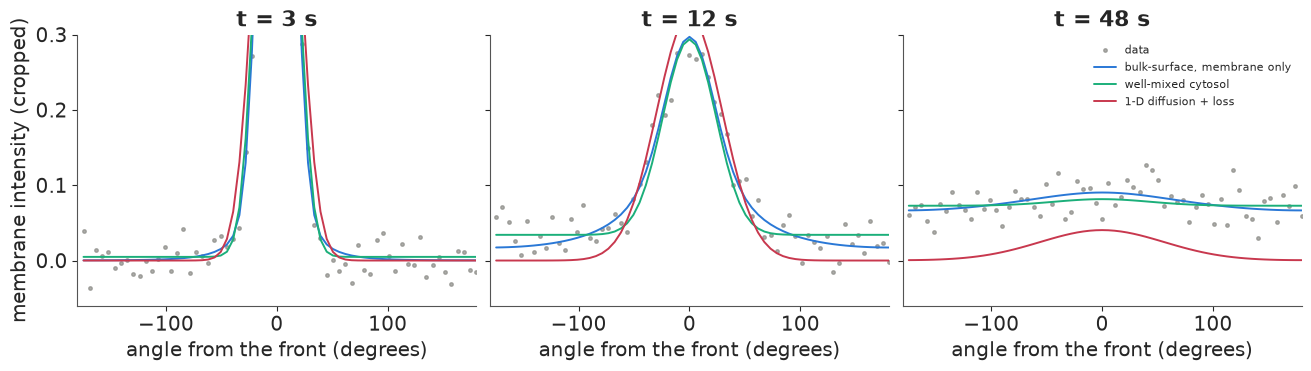

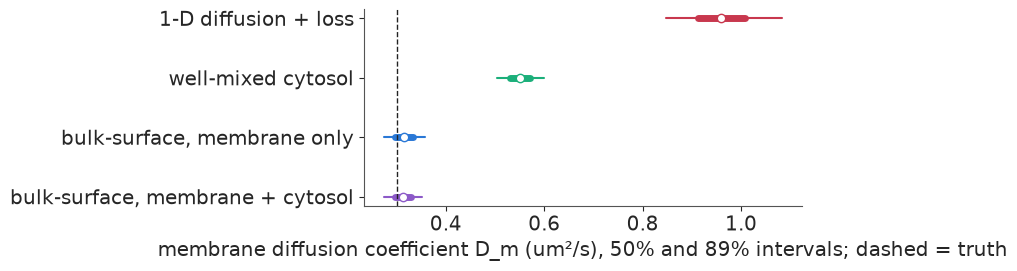

In [11]:
def posterior_mean_profile(label):
    p = post_all[label]
    idx = rng.choice(p.sizes["sample"], 200, replace=False)
    if label.startswith("bulk"):
        U = [evolve({q: float(p[q][i]) for q in ["Dc", "Dm", "kon", "koff"]}, u0, TIMES)[:, NB:] for i in idx]
    elif label.startswith("1-D"):
        U = [(a0_mem * np.exp(-(float(p["Dm"][i]) * LAM_RING + float(p["k_loss"][i]))[None] * TIMES[:, None])) @ COSN.T
             for i in idx]
    else:
        U = []
        for i in idx:
            Dm_, kon_, koff_ = (float(p[q][i]) for q in ["Dm", "kon", "koff"])
            a_rest = a0_mem[1:] * np.exp(-(Dm_ * LAM_RING[1:] + koff_)[None] * TIMES[:, None])
            m_tot0 = a0_mem[0] * np.sqrt(NT) * LSEG
            rate = koff_ + kon_ * PERIM / DISK
            m_eq = m_tot0 * (kon_ * PERIM / DISK) / rate
            a_0 = (m_eq + (m_tot0 - m_eq) * np.exp(-rate * TIMES)) / LSEG / np.sqrt(NT)
            U.append(np.c_[a_0, a_rest] @ COSN.T)
    return np.mean(U, axis=0)


post_all = {k: v.posterior.to_dataset().stack(sample=("chain", "draw")) for k, v in fits.items()}
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
mcols = dict(zip(membrane_fits, [BLUE, AQUA, RED]))
for ax, k in zip(axes, [1, 3, 5]):
    ax.plot(np.rad2deg(TH[order]), Y_mem[k, order], "o", ms=2.5, color=GREY, alpha=0.7, label="data")
    ax.set(title=f"t = {TIMES[k]:.0f} s", xlabel="angle from the front (degrees)", xlim=(-180, 180))
for label in membrane_fits:
    prof = posterior_mean_profile(label)
    for ax, k in zip(axes, [1, 3, 5]):
        ax.plot(np.rad2deg(TH[order]), prof[k, order], color=mcols[label], lw=1.4, label=label)
axes[0].set(ylabel="membrane intensity (cropped)", ylim=(-0.06, 0.3))
axes[2].legend(fontsize=8)

fig, ax = plt.subplots(figsize=(8, 2.6))
for y_, label in enumerate(["bulk-surface, membrane + cytosol", *membrane_fits]):
    d = post_all[label]["Dm"].values
    q = np.quantile(d, [0.055, 0.25, 0.5, 0.75, 0.945])
    col = mcols.get(label, PURPLE)
    ax.plot(q[[0, 4]], [y_, y_], color=col, lw=1.5)
    ax.plot(q[[1, 3]], [y_, y_], color=col, lw=5)
    ax.plot(q[2], y_, "o", color="white", mec=col)
ax.axvline(TRUE["Dm"], color=INK, ls="--", lw=1)
ax.set(yticks=range(4), yticklabels=["bulk-surface, membrane + cytosol", *membrane_fits],
       xlabel="membrane diffusion coefficient D_m (um²/s), 50% and 89% intervals; dashed = truth");

The residual pattern is in the tails (the plots are cropped at 0.3 to show them).
The 1-D model cannot put anything there except by diffusing it along the membrane: even with its
large $D_m$ its tails are too thin at 12 s and the far side stays empty at 48 s. The well-mixed
model fills the far side at once and evenly, where the data rise gradually from the patch
outwards (12 s). Only the bulk-surface model follows both the
near-patch shape and the slow rise at the back.

The practical lesson is general: **an effective diffusion coefficient fitted along a surface
absorbs every transport route that is not in the model**. It is not a property of the
membrane, will not transfer to cells of another size (the cytosolic shortcut scales with $R$),
and gives wrong answers to questions about the membrane, such as how fast a membrane-bound
signal spreads.

## 8 · From the posterior to signaling predictions

Suppose this protein is a signal (section 4), activated at the front and switched off by a GAP
on the membrane ($k_m = 0.05$ /s) and by a cytosolic phosphatase whose rate we vary, for instance
by a phosphatase inhibitor. With the transport posterior from the membrane + cytosol fit, what
fraction of the front signal reaches the back of the cell and its centre? And what would we
predict from the 1-D analysis, which (with its fitted $D_m$ and loss rate) has only the membrane
route?

1-D membrane model: back/front 2.5e-04 at every k_c
k_c =  0.05/s: bulk-surface back/front 7.8e-02 (90% 7.3e-02-8.3e-02), truth 7.8e-02, ratio to the 1-D prediction 3.1e+02
k_c =  0.47/s: bulk-surface back/front 5.2e-03 (90% 4.2e-03-6.2e-03), truth 5.0e-03, ratio to the 1-D prediction 2.0e+01
k_c =  4.74/s: bulk-surface back/front 4.6e-07 (90% 2.3e-07-7.6e-07), truth 3.8e-07, ratio to the 1-D prediction 1.8e-03


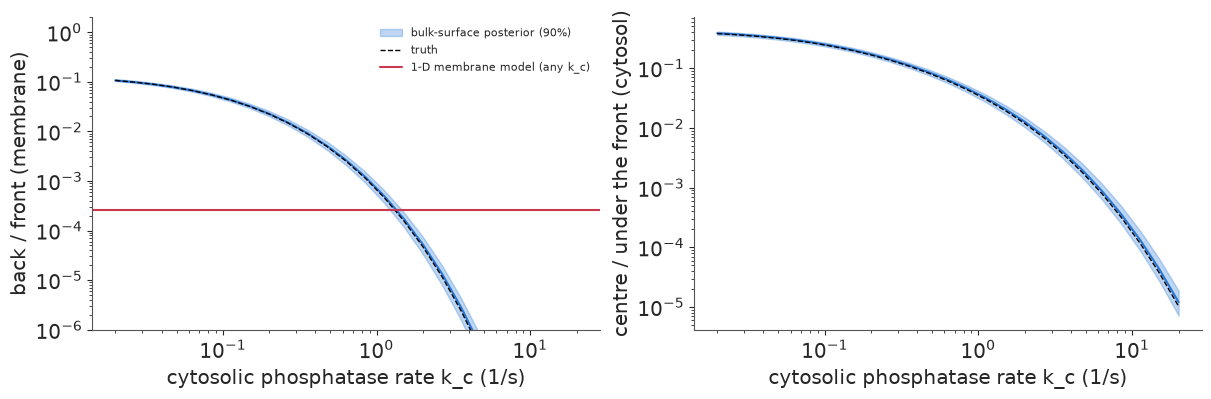

In [12]:
KC_PRED = np.geomspace(0.02, 20, 25)
p_bs = post_all["bulk-surface, membrane + cytosol"]
idx = rng.choice(p_bs.sizes["sample"], 300, replace=False)
pred = np.array([[reach(dict({q: float(p_bs[q][i]) for q in ["Dc", "Dm", "kon", "koff"]}, kc=kc, km=KM))[:2]
                  for kc in KC_PRED] for i in idx])                     # (draws, kc, 2)
truth_pred = np.array([reach(dict(TRUE, kc=kc, km=KM))[:2] for kc in KC_PRED])

# 1-D model: steady state of D m'' - (k_loss + k_m) m + source on the ring, per cosine mode
p_1d = post_all["1-D diffusion + loss"]
src_modes = COSN.T @ SOURCE
b_over_f_1d = []
for i in rng.choice(p_1d.sizes["sample"], 300, replace=False):
    m_ = COSN @ (src_modes / (float(p_1d["Dm"][i]) * LAM_RING + float(p_1d["k_loss"][i]) + KM))
    b_over_f_1d.append(m_[np.abs(TH) > np.pi - 0.05].mean() / m_[np.abs(TH) < 0.05].mean())
b_over_f_1d = np.array(b_over_f_1d)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, j, lab in zip(axes, [0, 1], ["back / front (membrane)", "centre / under the front (cytosol)"]):
    lo, mid, hi = np.quantile(pred[:, :, j], [0.05, 0.5, 0.95], axis=0)
    ax.fill_between(KC_PRED, lo, hi, color=BLUE, alpha=0.3, label="bulk-surface posterior (90%)")
    ax.plot(KC_PRED, mid, color=BLUE)
    ax.plot(KC_PRED, truth_pred[:, j], "k--", lw=1, label="truth")
    ax.set(xscale="log", yscale="log", xlabel="cytosolic phosphatase rate k_c (1/s)", ylabel=lab)
axes[0].axhline(np.median(b_over_f_1d), color=RED, lw=1.5, label="1-D membrane model (any k_c)")
axes[0].legend(fontsize=8)
axes[0].set_ylim(1e-6, 2)
print(f"1-D membrane model: back/front {np.median(b_over_f_1d):.1e} at every k_c")
for kc_ in [0.05, 0.5, 5.0]:
    i1 = np.argmin(np.abs(np.log(KC_PRED / kc_)))
    q = np.quantile(pred[:, i1, 0], [0.05, 0.5, 0.95])
    print(f"k_c = {KC_PRED[i1]:5.2f}/s: bulk-surface back/front {q[1]:.1e} (90% {q[0]:.1e}-{q[2]:.1e}), "
          f"truth {truth_pred[i1, 0]:.1e}, ratio to the 1-D prediction {q[1] / np.median(b_over_f_1d):.1e}")

The posterior predictions are tight and follow the truth. With a slow phosphatase the back of
the cell carries about 8% of the front's signal and the centre about 40% of the level under the
front; from $k_c = 0.5$ to 5 /s the back-to-front ratio falls ten-thousandfold. None of this was measured in a signaling experiment: the transport came from
photoactivation and the deactivation rates are scenario inputs. Combining the two is what a
mechanistic model is for.

The 1-D model gives **one number at every phosphatase level** (red), because it has no cytosol
for the phosphatase to act in. It is wrong in both directions: 300 times too low when the
phosphatase is slow (it cannot deliver anything through the cytosol), and 500 times too high
when the phosphatase is fast, because its inflated $D_m$ credits the membrane with transport that the
phosphatase has in fact shut down. It says nothing about the nucleus at all. Both analyses fit the
same membrane data; only the one with the cytosol can answer questions about the rest of the
cell.

## 9 · Polarity: a front that holds only if the membrane is slow and the cytosol fast

So far everything was linear. Cells also use bulk-surface dynamics to make decisions. A classic
example is **wave-pinning** (Mori, Jilkine & Edelstein-Keshet 2008), a minimal model of cell
polarity for Rho-family GTPases. The active form $a$ lives on the membrane; the inactive form $b$ lives in
the cytosol. Activation at the membrane is self-reinforcing:

$$f(a, b) = b|_\Gamma \Big(k_0 + \gamma \frac{a^2}{K^2 + a^2}\Big) - \delta\, a,$$

a flux from the cytosol onto the membrane (per µm of membrane per s). $\partial_t a = D_a
\partial_s^2 a + f$ on the membrane, $\partial_t b = D_b \nabla^2 b$ in the cytosol, and
$-D_b \partial_n b = f$ at the boundary. The total amount is conserved. For a range of cytosolic
levels the membrane is **bistable** (a low and a high active state). A transient stimulus at the
front makes a high-state patch that spreads, which uses up cytosolic $b$, until the front stops
("pins") where the two states balance. The result is a stable polarised cell with a front and a
back.

The model needs a bulk and a surface, and the two diffusion coefficients do opposite jobs: the
front must be sharp and stay put on the membrane (slow $D_a$), and depletion of $b$ must be felt
all over the cell at once (fast $D_b$). We simulate it on the same mesh (implicit steps for the
diffusion, a sparse LU factorised once, explicit steps for the reaction) with $k_0 = 0.335$,
$\gamma = 5$, $K = 1$, $\delta = 1$ /s and a uniform start at the low state with $b = 0.39$ per
µm², inside the bistable range. The stimulus is a 10-second, 4-fold boost of $k_0$ at the front.
Then we map the outcome over $(D_a, D_b)$ and overlay the transport posterior of section 6, as if the
protein we measured had these kinetics.

42 simulations in 39 s


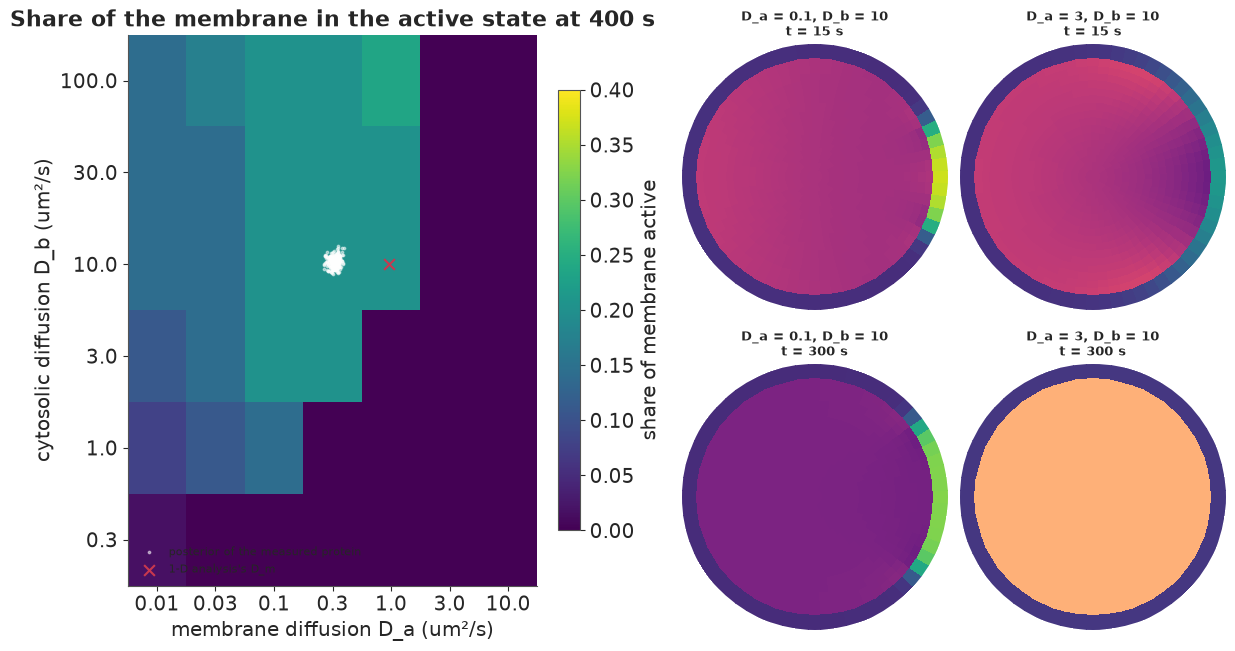

In [13]:
WP = dict(k0=0.335, gamma=5.0, K=1.0, delta=1.0, b0=0.39)
ag = np.linspace(0, 10, 100001)
g = WP["b0"] * (WP["k0"] + WP["gamma"] * ag**2 / (WP["K"] ** 2 + ag**2)) - WP["delta"] * ag
A_LOW = ag[np.argmax(np.sign(g[:-1]) != np.sign(g[1:]))]


def wave_pinning(Da, Db, T=400.0, dt=0.02, snap_every=None):
    lu = splu((sp.diags(MASS) + dt * (Db * BASIS["Dc"] + Da * BASIS["Dm"])).tocsc())
    u = np.r_[np.full(NB, WP["b0"]), np.full(NT, A_LOW)]
    stim = np.exp(-(TH / 0.35) ** 2)
    snaps = []
    for step in range(int(T / dt)):
        a, bR = u[NB:], u[OUTER]
        k0 = WP["k0"] * (1 + 3.0 * stim * (step * dt < 10.0))
        f = bR * (k0 + WP["gamma"] * a**2 / (WP["K"] ** 2 + a**2)) - WP["delta"] * a
        r = np.zeros(NTOT)
        r[NB:] = f * LSEG
        r[OUTER] -= f * LSEG
        u = lu.solve(MASS * u + dt * r)
        if snap_every and (step + 1) % snap_every == 0:
            snaps.append(u.copy())
    return u, snaps


DA_GRID = np.array([0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0])
DB_GRID = np.array([0.3, 1.0, 3.0, 10.0, 30.0, 100.0])
t0 = time.time()
polar_frac = np.zeros((len(DB_GRID), len(DA_GRID)))
for i, Db in enumerate(DB_GRID):
    for j, Da in enumerate(DA_GRID):
        u_end, _ = wave_pinning(Da, Db)
        polar_frac[i, j] = np.mean(u_end[NB:] > 0.6)          # share of membrane in the high state
print(f"{polar_frac.size} simulations in {time.time() - t0:.0f} s")

fig = plt.figure(figsize=(12, 6.4))
left, right = fig.subfigures(1, 2, width_ratios=[1.15, 1])
ax = left.subplots()
im = ax.pcolormesh(np.arange(len(DA_GRID) + 1), np.arange(len(DB_GRID) + 1), polar_frac, cmap="viridis",
                   vmin=0, vmax=0.4)
ax.set(xticks=np.arange(len(DA_GRID)) + 0.5, xticklabels=DA_GRID, yticks=np.arange(len(DB_GRID)) + 0.5,
       yticklabels=DB_GRID, xlabel="membrane diffusion D_a (um²/s)", ylabel="cytosolic diffusion D_b (um²/s)",
       title="Share of the membrane in the active state at 400 s")
left.colorbar(im, ax=ax, label="share of membrane active", shrink=0.8)
# posterior of the measured protein (section 6), in grid coordinates (log interpolation)
to_grid = lambda v, grid: np.interp(np.log(v), np.log(grid), np.arange(len(grid))) + 0.5
ax.scatter(to_grid(p_bs["Dm"].values[idx], DA_GRID), to_grid(p_bs["Dc"].values[idx], DB_GRID), s=3,
           color="white", alpha=0.5, label="posterior of the measured protein")
ax.scatter(to_grid(np.median(p_1d["Dm"].values), DA_GRID), to_grid(TRUE["Dc"], DB_GRID), marker="x",
           s=60, color=RED, label="1-D analysis's D_m")
ax.legend(fontsize=8, loc="lower left", facecolor="white", framealpha=0.9)
for c, (Da, Db, lab) in enumerate([(0.1, 10.0, "D_a = 0.1, D_b = 10"), (3.0, 10.0, "D_a = 3, D_b = 10")]):
    _, snaps = wave_pinning(Da, Db, T=300.0, snap_every=int(15 / 0.02))
    for r_, k_ in enumerate([0, -1]):
        axp = right.add_subplot(2, 2, 1 + c + 2 * r_, projection="polar")
        cell_image(axp, snaps[k_], cmin=0.34, cmax=0.40, mmax=1.4,
                   title=f"{lab}\nt = {15 * (k_ % len(snaps) + 1)} s")

The animation plays the two cells of the snapshots side by side for 5 minutes, with the membrane
profile $a(\theta)$ of both underneath.

In [14]:
snap_dt = 6.0
wp_runs = {lab: wave_pinning(Da, 10.0, T=300.0, snap_every=int(snap_dt / 0.02))[1]
           for lab, Da in [("D_a = 0.1", 0.1), ("D_a = 3", 3.0)]}
fig = plt.figure(figsize=(10, 7), dpi=72)
top, bottom = fig.subfigures(2, 1, height_ratios=[1.3, 1])
pax = [top.add_subplot(1, 2, c + 1, projection="polar") for c in range(2)]
lax = bottom.subplots()
prof = {lab: lax.plot(np.rad2deg(TH[order]), snaps_[0][NB:][order], color=col, lw=2, label=lab)[0]
        for (lab, snaps_), col in zip(wp_runs.items(), [BLUE, ORANGE])}
lax.set(xlabel="angle from the front (degrees)", ylabel="active form a on the membrane", ylim=(0, 1.5),
        xlim=(-180, 180))
lax.legend(fontsize=8)
suptitle = fig.suptitle("")
plt.close(fig)


def update(k):
    for ax, (lab, snaps_) in zip(pax, wp_runs.items()):
        ax.clear()
        cell_image(ax, snaps_[k], cmin=0.34, cmax=0.40, mmax=1.4, title=f"{lab}, D_b = 10")
        prof[lab].set_ydata(snaps_[k][NB:][order])
    suptitle.set_text(f"t = {snap_dt * (k + 1):.0f} s (stimulus at the front for the first 10 s)")
    return []


anim = animation.FuncAnimation(fig, update, frames=len(wp_runs["D_a = 0.1"]), interval=150)
HTML(anim.to_jshtml(default_mode="once"))

The map has a clear polarised region: **slow membrane diffusion and fast cytosolic diffusion**.
With a fast membrane ($D_a \gtrsim 3$ µm²/s) the stimulated patch spreads and dilutes faster than
it can reinforce itself, and the cell returns to uniform. With a slow cytosol ($D_b \lesssim 1$
µm²/s, and more so the faster the membrane) the region under the patch is depleted of $b$ at
once, the patch starves before it can grow, and again nothing happens. The snapshots (right; the
cytosol on a narrow scale, 0.34-0.40, to show the depletion) show a front that forms and holds,
and one that fades. In the polarised cell the whole cytosol is depleted (darker at 300 s): that
global depletion is what stops the front. With very slow membrane diffusion ($D_a = 0.01$) the share is smaller only
because the front moves slowly (its speed scales as $\sqrt{D_a}$) and has not reached its pinned
position by 400 s.

The measured protein's posterior (white) sits inside the polarised region. The 1-D analysis's
$D_m$ (red cross) is also inside, but next to the edge: for a protein a little closer to the
boundary, the two analyses would disagree about whether the cell can polarise. The kinetic
parameters here are illustrative, not fitted; with them, polarity is a property of **both**
diffusion coefficients, and a membrane-only analysis would have no $D_b$ to put on the map.

## Summary

- **Bulk-surface reaction-diffusion** couples a 2-D PDE in the cytosol to a 1-D PDE on the
  membrane through a flux (Robin) boundary condition. The run length $\ell_m$ on the membrane,
  the reach $\ell_c$ in the cytosol, the residence time and the crossing time decide how signals
  travel (sections 1, 3).
- **Exact and fast**: finite volumes on a disk, an angular Fourier decomposition (33 problems of
  size 17 instead of one of size 1,025) and a symmetrised `eigh` give exact time courses that are
  differentiable in PyMC. Sampling takes about a minute (sections 2, 6).
- **Long-range transport along the membrane goes through the cytosol.** Membrane diffusion
  alone needs minutes to reach the back of a 20 µm cell and half an hour to even out; cytosolic
  excursions take seconds. Cytosolic phosphatases and cell size limit how far signals reach (sections 3-4).
- **The membrane profile carries a fingerprint of the cytosol**: the bulk-surface model
  identifies $D_c$ even from membrane data alone (section 6).
- **1-D analyses mistake the cytosolic shortcut for membrane diffusion**: a threefold, confidently
  wrong $D_m$; the well-mixed cytosol limit halves the error but keeps the bias. LOO ranks the
  models correctly (section 7). The simplified models also give qualitatively wrong predictions
  about signal reach (section 8).
- **Polarity by wave-pinning** needs a slow membrane and a fast cytosol (section 9).

## Try it yourself

1. **Shape.** Real cells are not round. Replace the disk by an ellipse (map the polar mesh with
   $x = a r\cos\theta$, $y = b r\sin\theta$ and recompute the face lengths and areas; the modes no
   longer decouple, so use a sparse solver). Meyers et al. and Rangamani et al. (2013) predict that
   signals are stronger at the tips of elongated cells, where the membrane-to-volume ratio is
   higher. Reproduce that, and ask how much the posterior of section 6 changes if the cell imaged
   was elongated but modelled as round.
2. **Experimental design.** Which imaging times, and how many, determine $D_m$ and $D_c$ best
   for a fixed photon budget? Compute the posterior width of each for several schedules (or use
   the Fisher information from the model's gradient), and compare with imaging the cytosol vs not.
3. **Fitting polarity.** Simulate noisy images of a polarising cell (section 9) and infer
   $D_a$, $D_b$ and $k_0$ from the pinned front's width and position with a time-stepping model in
   `scan`. Which features of the pinned state are informative, and which parameter combinations
   does steady-state data alone leave unidentified?